In [ ]:
! pip install opencxr

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencxr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 52.5 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=8d50f1c94b43a01dcd7cd7a9050667e0acf91a015b8f4a7328f55beb1185c67a
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


### Muntatge de Google Drive a Google Colab

Aquesta instrucció munta el **Google Drive** dins l’entorn de **Google Colab**, permetent accedir als fitxers personals (datasets, models, resultats) com si fossin part del sistema de fitxers local.

Un cop muntat, el contingut del Drive és accessible sota el camí:



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Definició de rutes del dataset NODE21

En aquest fragment es defineixen les rutes principals utilitzades per accedir al **dataset NODE21** dins de Google Drive:

- **`BASE_PATH`**: directori arrel on es troben les dades processades.
- **`PATH_IMAGES`**: carpeta que conté les imatges (radiografies).
- **`PATH_METADATA`**: fitxer CSV amb el *metadata* del dataset (labels, anotacions, etc.).

Finalment, es mostra per pantalla el valor efectiu de les rutes per verificar que apunten correctament als recursos esperats dins de l’entorn de Colab.

Aquesta comprovació és útil per evitar errors d’accés a fitxers abans de carregar dades o iniciar l’entrenament dels models.


In [ ]:
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"
PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/metadata_balanced.csv"

print(PATH_IMAGES)
print(PATH_METADATA)

/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images
/content/drive/MyDrive/ML/DATASETS/NODE21/metadata_balanced.csv


### Càrrega i anàlisi bàsica del *metadata*

Es carrega el fitxer de *metadata* en un `DataFrame`, es construeix la ruta completa de cada imatge i es mostra un exemple de les primeres files. Finalment, es compta el nombre de casos **negatius** i **positius** per analitzar el balanç de classes del dataset.


In [ ]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)
df["file_path"] = df["img_name"].apply(
    lambda x: os.path.join(PATH_IMAGES, x)
)

df.head()
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()
print("Negativos:", num_neg)
print("Positivos:", num_pos)



Negativos: 3748
Positivos: 3748


In [ ]:
!ls "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

images	metadata.csv  simulated_metadata.csv


### Visualització d’una imatge del dataset

Es carrega una imatge mèdica del dataset utilitzant el lector `read_file`, es corregeix la seva orientació mitjançant una rotació i un volteig horitzontal (propis del NODE21) i es mostra en escala de grisos per a una inspecció visual ràpida.


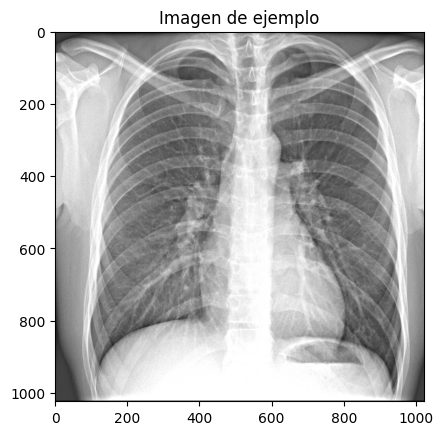

In [ ]:
from opencxr.utils.file_io import read_file, write_file
import matplotlib.pyplot as plt
import numpy as np

sample_path = df["file_path"].iloc[1001]
img_np, spacing, _ = read_file(sample_path)
img_np = np.rot90(img_np, k=3)
img_np = np.fliplr(img_np)

plt.imshow(img_np, cmap="gray")
plt.title("Imagen de ejemplo")
plt.axis("on")
plt.show()

### Pipeline de classificació multicanal de radiografies (NODE21)

Es defineix un *pipeline* complet per a la classificació binària de nòduls pulmonars. Les imatges es carreguen des del *metadata*, es normalitzen i es transformen en un format **multicanal (4 canals)**: imatge original, CLAHE, vores Canny i *Unsharp Mask*. Durant l’entrenament s’aplica *data augmentation* lleu (flip, rotació i soroll).

El conjunt de dades es divideix en **train/test (80/20)** i es gestionen mostres invàlides amb un `collate` personalitzat. El model s’entrena amb *CrossEntropyLoss* i *Adam*, monitoritzant pèrdua i *accuracy*. Finalment, el rendiment s’avalua mitjançant *classification report* i *confusion matrix*, i es visualitzen els canals per validar el preprocessament.


Device: cuda
Negativos: 3748
Positivos: 3748
Total imágenes válidas: 7496


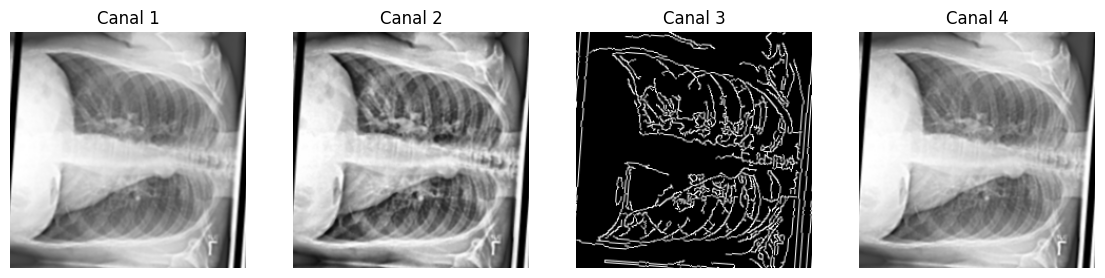

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import cv2
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from opencxr.utils.file_io import read_file


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ============================================================
# 2. RUTES
# ============================================================
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata.csv"
PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/metadata_balanced.csv"

df = pd.read_csv(PATH_METADATA)

num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("Negativos:", num_neg)
print("Positivos:", num_pos)

df = df[df["file_path"].apply(os.path.exists)].reset_index(drop=True)
print("Total imágenes válidas:", len(df))



# ============================================================
# 3. DATA AUGMENTATION
# ============================================================
def augment_image(img4):
    # img4: numpy array (4,H,W)

    C, H, W = img4.shape

    # Flip horizontal
    if np.random.rand() < 0.5:
        img4 = img4[:, :, ::-1].copy()

    # Rotació suau
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-7, 7)
        M = cv2.getRotationMatrix2D((W/2, H/2), angle, 1.0)

        rotated = []
        for c in range(C):
            rc = cv2.warpAffine(img4[c], M, (W, H),
                                flags=cv2.INTER_LINEAR,
                                borderMode=cv2.BORDER_REFLECT_101)
            rotated.append(rc)
        img4 = np.stack(rotated, axis=0)

    # Renou gaussia
    if np.random.rand() < 0.3:
        noise = np.random.normal(0.0, 0.03, img4.shape)
        img4 = np.clip(img4 + noise, 0.0, 1.0)

    return img4.copy()



# ============================================================
# 4. DATASET MULTICANAL (4 CANALS)
# ============================================================
class CXRClassificationDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]
        path = row["file_path"]

        try:
            img_np, _, _ = read_file(path)  # shape (H,W)
        except:
            return {"error": True}

        # Normaliztar a [0,1]
        img = img_np.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Resize
        img = cv2.resize(img, (224, 224))

        # -------------------------------------------------------------
        # CANAL 1 ORIGINAL
        # CANAL 2 CLAHE
        # CANAL 3 BORDES CANNY
        # CANAL 4 Unsharp Mask
        # -------------------------------------------------------------
        img_255 = (img * 255).astype(np.uint8)

        # Canal 1
        ch1 = img

        # Canal 2: CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        ch2 = clahe.apply(img_255).astype(np.float32) / 255.0

        # Canal 3: Canny
        ch3 = cv2.Canny(img_255, 50, 150).astype(np.float32) / 255.0

        # -------------------------------------------------------
        # Canal 4: Unsharp Mask
        # -------------------------------------------------------
        # Suavizamos la imagen
        blur = cv2.GaussianBlur(img, (5,5), 1.0)

        # Aplicamos unsharp mask: resalta bordes suaves tipo nódulo
        unsharp = cv2.addWeighted(src1=img, alpha=1.5,
                                  src2=blur, beta=-0.5,
                                  gamma=0)

        # Aseguramos rango [0,1]
        ch4 = np.clip(unsharp, 0.0, 1.0).astype(np.float32)

        # Stack → 4 canales
        img4 = np.stack([ch1, ch2, ch3, ch4], axis=0)


        # Augmentación
        if self.augment:
            img4 = augment_image(img4)

        return {
            "error": False,
            "image": torch.tensor(img4, dtype=torch.float32),
            "label": torch.tensor(row["label"], dtype=torch.long)
        }



# ============================================================
# 5. COLLATE
# ============================================================
def custom_collate(batch):
    batch = [b for b in batch if b is not None and not b["error"]]
    if len(batch) == 0:
        return None
    images = torch.stack([b["image"] for b in batch])
    labels = torch.stack([b["label"] for b in batch])
    return images, labels



# ============================================================
# 6. SPLIT TRAIN/TEST EN MULTICANAL
# ============================================================
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = CXRClassificationDataset(train_df, augment=True)
test_dataset  = CXRClassificationDataset(test_df, augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)

test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)



# ============================================================
# 7. VISUALIZACIÓN DE LOS 4 CANALES
# ============================================================
batch = next(iter(train_loader))
imgs, labels = batch

plt.figure(figsize=(14,4))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(imgs[0,i].cpu(), cmap="gray")
    plt.title(f"Canal {i+1}")
    plt.axis("off")
plt.show()



# ============================================================
# 8. ENTRENAMIENTO UNIVERSAL
# ============================================================
def train_model(model, train_loader, test_loader=None, epochs=5):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in loop:
            if batch is None:
                continue

            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            loop.set_postfix(loss=loss.item())

        print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}  Acc={correct/total:.4f}")

    return model



# ============================================================
# 9. EVALUACIÓN
# ============================================================
def evaluate_model(model, loader):

    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue

            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    print("\n=== Classification Report ===")
    print(classification_report(all_labels, all_preds, digits=4))

    print("\n=== Confusion Matrix ===")
    print(confusion_matrix(all_labels, all_preds))



In [ ]:
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("Negativos:", num_neg)
print("Positivos:", num_pos)


Negativos: 3748
Positivos: 3748


### Adaptació i entrenament d’EfficientNet-B0 multicanal

S’utilitza **EfficientNet-B0** preentrenada a *ImageNet* i s’adapta per treballar amb **4 canals d’entrada** (original, CLAHE, Canny i Unsharp) substituint la primera capa convolucional. La capa final de classificació es redefineix per a un problema **binari (2 classes)**.

El model s’entrena sobre el *dataset* multicanal utilitzant el *pipeline* definit prèviament i s’avalua amb mètriques estàndard (classification report i matriu de confusió).


In [ ]:
from torchvision import models
import torch.nn as nn

# 1. Cargar EfficientNet-B0 preentrenado
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# 2. Modificar la PRIMERA capa para aceptar 4 canales en lugar de 3
model.features[0][0] = nn.Conv2d(
    in_channels=4,
    out_channels=32,
    kernel_size=3,
    stride=2,
    padding=1,
    bias=False
)

# 3. Modificar la capa final (clasificador) a 2 clases
n = model.classifier[1].in_features
model.classifier[1] = nn.Linear(n, 2)

# 4. Enviar a GPU
model = model.to(device)

# 5. Entrenamiento y evaluación
model = train_model(model, train_loader, test_loader, epochs=20)
evaluate_model(model, test_loader)

Epoch 1/20: 100%|██████████| 188/188 [02:32<00:00,  1.23it/s, loss=0.279]


Epoch 1: Loss=0.4557  Acc=0.7819


Epoch 2/20: 100%|██████████| 188/188 [02:33<00:00,  1.23it/s, loss=0.0544]


Epoch 2: Loss=0.3121  Acc=0.8671


Epoch 3/20: 100%|██████████| 188/188 [02:32<00:00,  1.24it/s, loss=0.593]


...

Epoch 19/20: 100%|██████████| 188/188 [02:33<00:00,  1.23it/s, loss=0.0359]


Epoch 19: Loss=0.0436  Acc=0.9858


Epoch 20/20: 100%|██████████| 188/188 [02:32<00:00,  1.23it/s, loss=0.0625]

Epoch 20: Loss=0.0502  Acc=0.9823



=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9892    0.9720    0.9805       751
           1     0.9724    0.9893    0.9808       749

    accuracy                         0.9807      1500
   macro avg     0.9808    0.9807    0.9807      1500
weighted avg     0.9808    0.9807    0.9807      1500


=== Confusion Matrix ===
[[730  21]
 [  8 741]]


### Entrenament d’EfficientNet-B0 estàndard (3 canals)

Es carrega **EfficientNet-B0** preentrenada amb pesos d’*ImageNet* i es modifica únicament la capa final per adaptar-la a una **classificació binària**. El model treballa amb imatges RGB estàndard (3 canals), s’entrena durant unes poques èpoques com a **baseline** i s’avalua amb *classification report* i *confusion matrix*.


In [ ]:
from torchvision import models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
n = model.classifier[1].in_features
model.classifier[1] = nn.Linear(n, 2)
model = model.to(device)

model = train_model(model, train_loader, test_loader, epochs=5)
evaluate_model(model, test_loader)

### Guardat del model entrenat

Es desa l’estat del model entrenat (*state_dict*) en un fitxer `.pth` dins de Google Drive. Això permet **reutilitzar el model posteriorment** per a inferència o anàlisi explicativa sense necessitat de tornar-lo a entrenar.


In [ ]:
# === GUARDAR MODEL ===
MODEL_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/efficientnet_b0_multicanal_Unsharp_bo.pth"
torch.save(model.state_dict(), MODEL_PATH)

print("Model guardat a:", MODEL_PATH)

Model guardat a: /content/drive/MyDrive/ML/DATASETS/NODE21/efficientnet_b0_multicanal_Unsharp_bo.pth


In [ ]:
import numpy as np
import cv2
from opencxr.utils.file_io import read_file
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F


### Preprocessament d’una imatge individual (multicanal)

Aquesta funció carrega una imatge mèdica, la normalitza al rang \([0,1]\) i la redimensiona a **224×224**. A continuació, construeix una representació **multicanal de 4 canals**: imatge original, millora de contrast amb **CLAHE**, detecció de vores amb **Canny** i ressaltat de detalls mitjançant **Unsharp Mask**. Finalment, apila els canals i retorna el tensor preparat per a la inferència amb el model.


In [ ]:
def preprocess_single_image(path):
    try:
        img_np, _, _ = read_file(path)   
    except:
        return None, "Error leyendo imagen"

    # Normalizar
    img = img_np.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = cv2.resize(img, (224, 224))

    img_255 = (img * 255).astype(np.uint8)

    # Canal 1: Original
    ch1 = img

    # Canal 2: CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    ch2 = clahe.apply(img_255).astype(np.float32) / 255.0

    # Canal 3: Canny
    ch3 = cv2.Canny(img_255, 50, 150).astype(np.float32) / 255.0

    # Canal 4: Unsharp Mask
    blur = cv2.GaussianBlur(img, (5,5), 1.0)
    unsharp = cv2.addWeighted(src1=img, alpha=1.5,
                              src2=blur, beta=-0.5,
                              gamma=0)
    ch4 = np.clip(unsharp, 0.0, 1.0).astype(np.float32)

    # Stack 4 canales
    img4 = np.stack([ch1, ch2, ch3, ch4], axis=0)

    tensor = torch.tensor(img4, dtype=torch.float32).unsqueeze(0)  

    return tensor.to(device), None


### Predicció d’una imatge amb el model entrenat

A partir d’una imatge preprocessada en format multicanal, el model realitza una **inferència en mode avaluació**, calcula les probabilitats amb *softmax* i assigna la classe amb major confiança. El resultat s’etiqueta com **NÒDUL** o **NO NÒDUL**, retornant també el valor de confiança associat.


In [ ]:
def predict_image(path):
    tensor, error = preprocess_single_image(path)
    if error:
        print(error)
        return

    model.eval()
    with torch.no_grad():
        outputs = model(tensor)
        prob = torch.softmax(outputs, dim=1)
        pred_class = torch.argmax(prob).item()
        confidence = prob[0][pred_class].item()

    label = "NÒDUL" if pred_class == 1 else "NO NÒDUL"
    print(f"Predicció: {label}  (confiança: {confidence:.4f})")

    return pred_class, confidence


### Càrrega del model EfficientNet-B0 multicanal per inferència

Es recrea **exactament la mateixa arquitectura** utilitzada durant l’entrenament d’EfficientNet-B0, adaptant la primera capa convolucional per acceptar **4 canals d’entrada**. A continuació, es redefineix el cap de classificació per a **dues classes** i es carreguen els pesos guardats prèviament.

Aquest pas garanteix la **consistència estructural** entre entrenament i inferència, permetent utilitzar el model multicanal entrenat per a predicció i explicabilitat.


In [ ]:
from torchvision import models
import torch.nn as nn

# ----------------------------------------------------------
# 1. Crear EfficientNet-B0 EXACTAMENT com la que varem entrenar
# ----------------------------------------------------------
model = models.efficientnet_b0(weights=None)

# 1.A — Substituir la primera capa per acceptar 4 CANALS
old_conv = model.features[0][0]

new_conv = nn.Conv2d(
    in_channels=4,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

# Inicialitzem només per tenir la mateixa estructura
with torch.no_grad():
    new_conv.weight[:, :3] = old_conv.weight.clone()
    new_conv.weight[:, 3] = old_conv.weight.mean(dim=1)

model.features[0][0] = new_conv

# 1.B — Cap final de classificació (com al model entrenat)
n = model.classifier[1].in_features
model.classifier[1] = nn.Linear(n, 2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# ----------------------------------------------------------
# 2.carregar els  pesos correctament
# ----------------------------------------------------------
MODEL_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/efficientnet_b0_multicanal_Unsharp_bo.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model.eval()
print("Model de 4 canals carregat correctament sota inferència.")


Model de 4 canals carregat correctament sota inferència.


In [ ]:
PROVES XAI

### Generació de mapes Grad-CAM

Aquesta funció calcula **Grad-CAM** per explicar la decisió del model sobre una imatge concreta. Es registren *hooks* a l’última capa convolucional per capturar **activacions** i **gradients**, es fa *backpropagation* respecte a la classe d’interès i es combinen amb pesos mitjans dels gradients.

El resultat és un **mapa de calor** normalitzat, redimensionat a 224×224, que ressalta les regions de la imatge que han contribuït més a la predicció del model.


In [ ]:
def generate_gradcam(tensor, class_idx=None):
    model.eval()
    target_layer = model.features[-1]

    # --- Netegem hooks antics si existien ---
    if hasattr(model, "_gradcam_forward_hook"):
        model._gradcam_forward_hook.remove()
    if hasattr(model, "_gradcam_backward_hook"):
        model._gradcam_backward_hook.remove()

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    # Registrar hooks correctes
    model._gradcam_forward_hook = target_layer.register_forward_hook(forward_hook)
    model._gradcam_backward_hook = target_layer.register_full_backward_hook(backward_hook)

    # Forward
    output = model(tensor)
    if class_idx is None:
        class_idx = torch.argmax(output)

    # Backward
    model.zero_grad()
    output[0, class_idx].backward()

    # CAM
    grads = gradients[0]    # (1, C, H, W)
    acts  = activations[0]  # (1, C, H, W)

    weights = grads.mean(dim=(2,3), keepdim=True)
    cam = (weights * acts).sum(dim=1).squeeze()

    # RELU i conversió segura → FIX
    cam = torch.relu(cam).detach().cpu().numpy()

    # Normalitzar + resize
    cam = cv2.resize(cam, (224,224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    return cam





### Visualització de Grad-CAM sobre la imatge

Aquesta funció genera una **explicació visual de la predicció del model** mitjançant **Grad-CAM**. Primer es preprocessa la imatge i es calcula la classe predita amb la seva confiança. A continuació, es genera el mapa Grad-CAM corresponent a aquesta classe.

El mapa de calor obtingut es mostra de tres formes:
1. **Imatge original** (canal original de la RX).
2. **Heatmap Grad-CAM**, que indica les regions més rellevants per a la decisió del model.
3. **Superposició** de la RX amb el mapa Grad-CAM, facilitant la interpretació clínica de quines zones han influït més en la predicció.


In [ ]:
def show_gradcam(path):
    tensor, error = preprocess_single_image(path)
    if error:
        print(error)
        return

    # Predicció
    pred_class, confidence = predict_image(path)

    # GradCAM
    heatmap = generate_gradcam(tensor, class_idx=pred_class)

    # Imatge original (canal 1)
    img = tensor.cpu().numpy()[0][0]

    # Superposició
    heatmap_color = cv2.applyColorMap((heatmap*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = (0.4*heatmap_color/255.0 + 0.6*np.repeat(img[:, :, None], 3, axis=2))

    # Mostrar
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap="gray")
    plt.title("Imatge original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(np.clip(overlay, 0,1))
    plt.title("Superposició RX + Heatmap")
    plt.axis("off")

    plt.show()


### Visualització multicanal de la imatge

Aquesta funció mostra els **quatre canals d’entrada** utilitzats pel model a partir d’una mateixa radiografia:
1. **Imatge original** normalitzada.
2. **CLAHE**, que millora el contrast local.
3. **Canny**, que ressalta les vores.
4. **Unsharp Mask**, que accentua estructures suaus com possibles nòduls.

Després de la visualització, es realitza la **predicció automàtica** del model indicant si hi ha nòdul o no. Opcionalment, es pot generar una explicació visual addicional mitjançant **Grad-CAM**.


In [ ]:
def show_multicanal(path):
    tensor, error = preprocess_single_image(path)
    if error:
        print(error)
        return

    img = tensor.cpu().numpy()[0] 

    plt.figure(figsize=(12,4))
    titles = ["Original", "CLAHE", "Canny Edges", "Unsharp Mask"]
    for i in range(4):
        plt.subplot(1,4,i+1)
        plt.imshow(img[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

    # Predicció
    predict_image(path)

    # Grad-CAM
    print("\nGenerant Grad-CAM…")
    #show_gradcam(path)


### Visualització de *bounding boxes* de nòduls

Aquesta funció permet **visualitzar gràficament les anotacions de nòduls** del dataset NODE21.  
El procés és el següent:

- Es carrega la imatge mèdica i es **normalitza** al rang \([0,1]\).
- Es corregeix l’**orientació específica del dataset** mitjançant una rotació i un volteig horitzontal.
- Es dibuixa la **caixa delimitadora (bounding box)** utilitzant les coordenades \((x, y)\) i les dimensions \((width, height)\) del *metadata*.
- Finalment, es mostra la imatge amb el **nòdul ressaltat**, facilitant la validació visual de les anotacions.

Aquesta visualització és especialment útil per comprovar la **coherència i qualitat de les etiquetes** abans d’entrenar o avaluar models.


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from opencxr.utils.file_io import read_file

def show_nodule_bbox(df, idx):
    row = df.iloc[idx]
    img_path = row["file_path"]

    try:
        img_np, _, _ = read_file(img_path)
    except:
        print("Error carregant imatge:", img_path)
        return

    # Normalitzar a [0,1]
    img = img_np.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # ===========================
    # Corregir rotació NODE21
    # ===========================
    img = np.rot90(img, k=3)   # 90 graus sentit horari
    img = np.fliplr(img)

    # Convertim per dibuixar
    img_disp = (img * 255).astype(np.uint8)
    img_color = cv2.cvtColor(img_disp, cv2.COLOR_GRAY2RGB)

    # Bounding box
    x = int(row["x"])
    print(x)

    y = int(row["y"])
    print(y)
    w = int(row["width"])
    h = int(row["height"])
    print(w)
    print(h)


    # Dibuixar rectangle
    cv2.rectangle(img_color, (x, y), (x + w, y + h), (255,0,0), 2)

    # Centre
    cx = x + w // 2
    cy = y + h // 2
    #cv2.circle(img_color, (cx, cy), 5, (0,255,0), -1)

    # Mostrar
    plt.figure(figsize=(6,6))
    plt.imshow(img_color)
    plt.title(f"Nòdul: {row['img_name']}")
    plt.axis("off")
    plt.show()



0
0
0
0


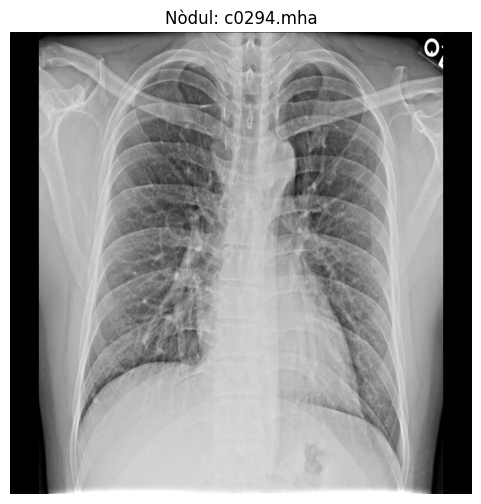

In [ ]:
idx = df[df["img_name"] == "c0294.mha"].index[0]

show_nodule_bbox(df, idx)

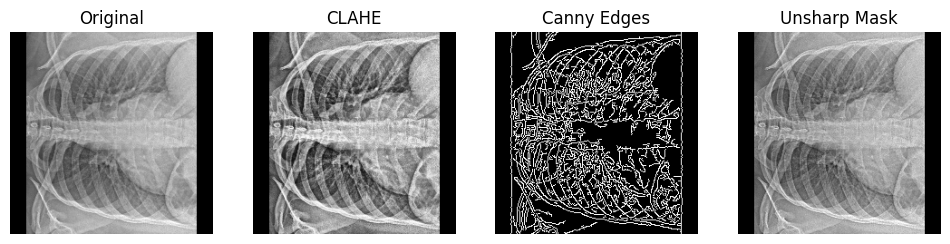

Predicció: NÒDUL  (confiança: 0.9902)

Generant Grad-CAM…


In [ ]:
show_multicanal("/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/c0296.mha")


### Preprocessament multicanal i predicció de nòduls

Aquest codi defineix el **pipeline d’inferència** per a la classificació de nòduls pulmonars a partir d’imatges del dataset NODE21 mitjançant un model CNN multicanal.

**Preprocessament (`preprocess_single_image`)**
- Es carrega la imatge mèdica i es **normalitza** al rang \([0,1]\).
- Es redimensiona a **224×224 píxels**.
- Es construeixen **4 canals complementaris**:
  1. **Original**: imatge base.
  2. **CLAHE**: millora del contrast local.
  3. **Canny**: detecció de vores.
  4. **Unsharp Mask**: ressalt de detalls suaus (potencialment nòduls).
- Els canals s’apilen en un tensor de mida `(1, 4, 224, 224)` llest per al model.

**Predicció (`predict_image`)**
- El tensor preprocessat s’introdueix al model entrenat.
- Es calcula la probabilitat amb *softmax*.
- Es retorna la classe (**NÒDUL / NO NÒDUL**) i la **confiança** associada.

**Visualització (`show_multicanal`)**
- Mostra gràficament els **quatre canals** generats.
- Executa la predicció sobre la mateixa imatge.

Aquest enfocament multicanal permet al model combinar **informació estructural, de contrast i de vores**, millorant la capacitat de detecció respecte a l’ús d’un sol canal.


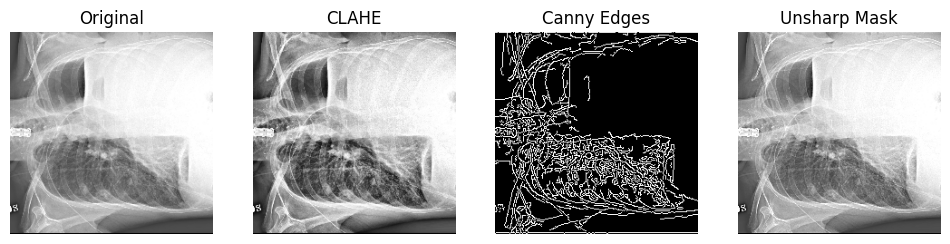

Predicció: NÒDUL  (confiança: 0.9958)


In [ ]:
import numpy as np
import cv2
from opencxr.utils.file_io import read_file
import torch
import matplotlib.pyplot as plt

def preprocess_single_image(path):
    try:
        img_np, _, _ = read_file(path)   
    except:
        return None, "Error leyendo imagen"

    # Normalizar
    img = img_np.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = cv2.resize(img, (224, 224))

    img_255 = (img * 255).astype(np.uint8)

    # ------------------------------------------------------
    # Canal 1: Original
    # ------------------------------------------------------
    ch1 = img

    # ------------------------------------------------------
    # Canal 2: CLAHE
    # ------------------------------------------------------
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    ch2 = clahe.apply(img_255).astype(np.float32) / 255.0

    # ------------------------------------------------------
    # Canal 3: Canny
    # ------------------------------------------------------
    ch3 = cv2.Canny(img_255, 50, 150).astype(np.float32) / 255.0

    # ------------------------------------------------------
    # Canal 4: Unsharp Mask
    # ------------------------------------------------------
    blur = cv2.GaussianBlur(img, (5,5), 1.0)
    unsharp = cv2.addWeighted(src1=img, alpha=1.5,
                              src2=blur, beta=-0.5,
                              gamma=0)
    ch4 = np.clip(unsharp, 0.0, 1.0).astype(np.float32)

    # ------------------------------------------------------
    # Stack 4 canales
    # ------------------------------------------------------
    img4 = np.stack([ch1, ch2, ch3, ch4], axis=0)

    tensor = torch.tensor(img4, dtype=torch.float32).unsqueeze(0)  

    return tensor.to(device), None



def predict_image(path):
    tensor, error = preprocess_single_image(path)
    if error:
        print(error)
        return

    model.eval()
    with torch.no_grad():
        outputs = model(tensor)
        prob = torch.softmax(outputs, dim=1)
        pred_class = torch.argmax(prob).item()
        confidence = prob[0][pred_class].item()

    label = "NÒDUL" if pred_class == 1 else "NO NÒDUL"
    print(f"Predicció: {label}  (confiança: {confidence:.4f})")

    return pred_class, confidence



def show_multicanal(path):
    tensor, error = preprocess_single_image(path)
    if error:
        print(error)
        return

    img = tensor.cpu().numpy()[0]  

    plt.figure(figsize=(12,4))
    titles = ["Original", "CLAHE", "Canny Edges", "Unsharp Mask"]
    for i in range(4):
        plt.subplot(1,4,i+1)
        plt.imshow(img[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

    predict_image(path)



# Probar
show_multicanal("/content/drive/MyDrive/ML/DATASETS/NODE21/augmented_pos/aug_pos_2222.mha")
